In [1]:
# core libraries
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # intractive plots

# for machine learning models and processing 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler,LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.model_selection import (StratifiedKFold,cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

# Advanced models
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import catboost as cb

import os;
os.listdir('/kaggle/input/')
song_data= pd.read_csv("/kaggle/input/datasets/yasserh/song-popularity-dataset/song_data.csv")
import warnings
warnings.filterwarnings("ignore",message="X does not have valid feature names")

print("all import successfully")


all import successfully


In [2]:
#initial inspection 
song_data.info()
song_data.head()
song_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_name         18835 non-null  object 
 1   song_popularity   18835 non-null  int64  
 2   song_duration_ms  18835 non-null  int64  
 3   acousticness      18835 non-null  float64
 4   danceability      18835 non-null  float64
 5   energy            18835 non-null  float64
 6   instrumentalness  18835 non-null  float64
 7   key               18835 non-null  int64  
 8   liveness          18835 non-null  float64
 9   loudness          18835 non-null  float64
 10  audio_mode        18835 non-null  int64  
 11  speechiness       18835 non-null  float64
 12  tempo             18835 non-null  float64
 13  time_signature    18835 non-null  int64  
 14  audio_valence     18835 non-null  float64
dtypes: float64(9), int64(5), object(1)
memory usage: 2.2+ MB


,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
count,18835.000000,1.883500e+04,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,52.991877,2.182116e+05,0.258539,0.633348,0.644995,0.078008,5.289196,0.179650,-7.447435,0.628139,0.102099,121.073154,3.959119,0.527967
std,21.905654,5.988754e+04,0.288719,0.156723,0.214101,0.221591,3.614595,0.143984,3.827831,0.483314,0.104378,28.714456,0.298533,0.244632
min,0.000000,1.200000e+04,0.000001,0.000000,0.001070,0.000000,0.000000,0.010900,-38.768000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,1.843395e+05,0.024100,0.533000,0.510000,0.000000,2.000000,0.092900,-9.044000,0.000000,0.037800,98.368000,4.000000,0.335000
50%,56.000000,2.113060e+05,0.132000,0.645000,0.674000,0.000011,5.000000,0.122000,-6.555000,1.000000,0.055500,120.013000,4.000000,0.527000
75%,69.000000,2.428440e+05,0.424000,0.748000,0.815000,0.002570,8.000000,0.221000,-4.908000,1.000000,0.119000,139.931000,4.000000,0.725000
max,100.000000,1.799346e+06,0.996000,0.987000,0.999000,0.997000,11.000000,0.986000,1.585000,1.000000,0.941000,242.318000,5.000000,0.984000


song_name           0
song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64
                        song_name  song_popularity  song_duration_ms  \
0      Boulevard of Broken Dreams               73            262333   
1                      In The End               66            216933   
2               Seven Nation Army               76            231733   
3                      By The Way               74            216933   
4               How You Remind Me               56            223826   
...                           ...              ...               ...   
18830              Let It Breathe               60            159645   
18831                     Answers               60            205666   
18832    

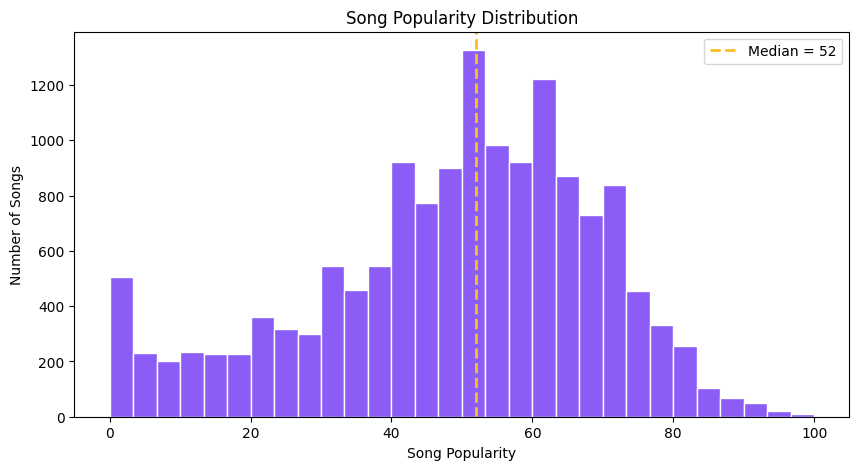

Correlation with song popularity:


,correlation
instrumentalness,-0.093032
audio_valence,-0.043963
liveness,-0.038553
acousticness,-0.031658
tempo,-0.029560
energy,-0.016468
song_duration_ms,-0.007766
speechiness,-0.001971
loudness,0.052114
danceability,0.056415


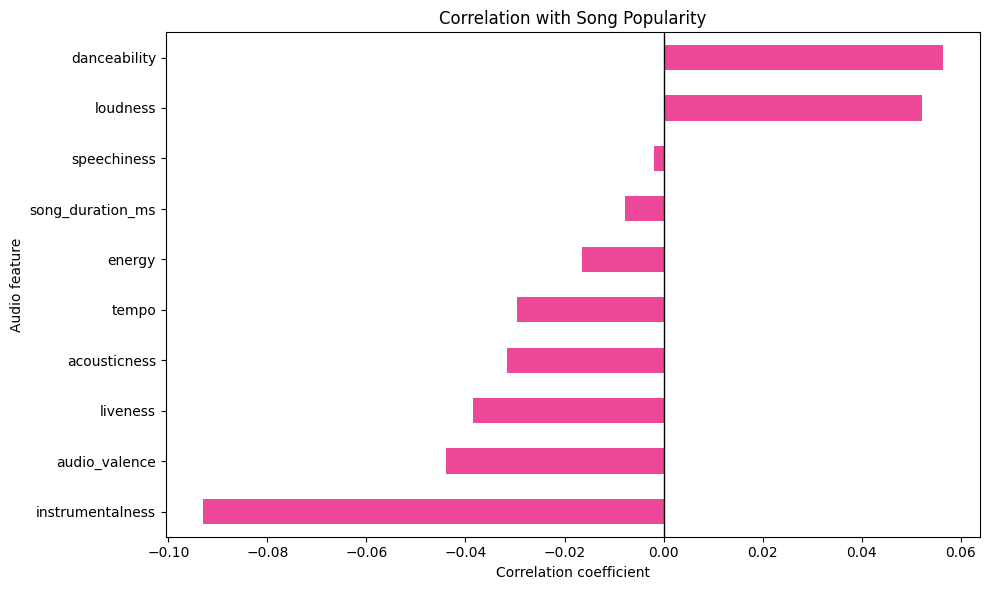

song_popularity: 0 outliers
song_duration_ms: 643 outliers
acousticness: 0 outliers
danceability: 111 outliers
energy: 45 outliers
instrumentalness: 3212 outliers
key: 0 outliers
liveness: 935 outliers
loudness: 564 outliers
audio_mode: 0 outliers
speechiness: 1821 outliers
tempo: 68 outliers
time_signature: 949 outliers
audio_valence: 0 outliers


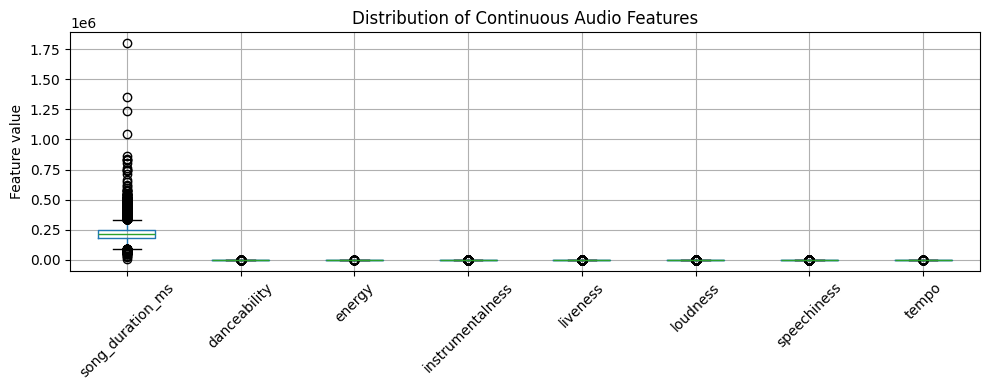

Negative durations: 0
Non-positive tempos: 2
Popularity outside 0–100: 0


In [3]:
#performing EDA
# checking for missing values 
print(song_data.isnull().sum())
#We checked for missing values in the dataset. None were found, so no imputation was required.

# checking for duplicates if there were it will be removed 
song_data = song_data.drop_duplicates()
print(song_data)

# population distribution
popularity_median = song_data["song_popularity"].median()
plt.figure(figsize=(10, 5))
plt.hist(song_data["song_popularity"],bins=30,color="#8B5CF6",edgecolor="white")
plt.axvline(popularity_median,color="#FBBF24",linestyle="--",linewidth=2,label=f"Median = {popularity_median:.0f}")
plt.title("Song Popularity Distribution")
plt.xlabel("Song Popularity")
plt.ylabel("Number of Songs")
plt.legend()
plt.show()

# correlation analysis
# excluded columns -> key, audio mode, time signature 
categorical_columns = ["key","audio_mode","time_signature"]
numeric_columns = song_data.select_dtypes(include=np.number).columns.tolist()
continuous_columns = [column for column in numeric_columns if column not in categorical_columns]
correlations = (song_data[continuous_columns].corr()["song_popularity"].drop("song_popularity").sort_values())

print("Correlation with song popularity:")
display(correlations.to_frame("correlation"))

# correlation plot
plt.figure(figsize=(10, 6))

correlations.plot(kind="barh",color="#EC4899")
plt.title("Correlation with Song Popularity")
plt.xlabel("Correlation coefficient")
plt.ylabel("Audio feature")
plt.axvline(0,color="black",linewidth=1)
plt.tight_layout()
plt.show()

#numbers of outliers per columns 
numeric_cols = song_data.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    Q1 = song_data[col].quantile(0.25)
    Q3 = song_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = song_data[(song_data[col] < lower_bound) | (song_data[col] > upper_bound)]
    print(f"{col}: {outliers.shape[0]} outliers")

plt.figure(figsize=(10, 4))

song_data[["song_duration_ms","danceability","energy","instrumentalness","liveness","loudness","speechiness","tempo"]].boxplot(rot=45)
plt.title("Distribution of Continuous Audio Features")
plt.ylabel("Feature value")
plt.tight_layout()
plt.show()

# Check impossible values
print("Negative durations:",(song_data["song_duration_ms"] < 0).sum())
print("Non-positive tempos:",(song_data["tempo"] <= 0).sum())
print("Popularity outside 0–100:",(~song_data["song_popularity"].between(0, 100)).sum())




In [4]:
# Feature engineering

song_data = song_data.copy()

# Convert source columns to numeric
for column in ["song_duration_ms","audio_valence","energy","song_popularity"]:
    if column in song_data.columns:
        song_data[column] = pd.to_numeric(song_data[column], errors="coerce")

# 1. Duration in minutes
song_data["duration_min"] = (song_data["song_duration_ms"] / 60000)

# 2. Mood index
song_data["mood_index"] = (song_data["audio_valence"]* song_data["energy"])

# 3. Create hit/non-hit target
popularity_median = song_data["song_popularity"].median()
song_data["is_hit"] = (song_data["song_popularity"]>= popularity_median).astype(int)

# 4. Treat selected columns as categorical
categorical_features = ["key","audio_mode","time_signature"]
for column in categorical_features:
    if column in song_data.columns:
        song_data[column] = song_data[column].astype("object")

# 5. Check the results
print("Popularity median:", popularity_median)
print("\nClass distribution:")
print(song_data["is_hit"].value_counts())

print("\nEngineered columns:")
print(["duration_min", "mood_index", "is_hit"])

display(
    song_data[["duration_min","mood_index","is_hit"]].head())

Popularity median: 52.0

Class distribution:
is_hit
1    7537
0    7389
Name: count, dtype: int64

Engineered columns:
['duration_min', 'mood_index', 'is_hit']


,duration_min,mood_index,is_hit
0,4.372217,0.323268,1
1,3.615550,0.315610,1
2,3.862217,0.150012,1
3,3.615550,0.192060,1
4,3.730433,0.439684,1


In [5]:
# model feature 
# Remove target columns and text column
X = song_data.drop(columns=["song_popularity","is_hit","song_name"],errors="ignore")

# Classification target
y = song_data["is_hit"]

# Treat these columns as categorical
categorical_features = ["key","audio_mode","time_signature"]
for column in categorical_features:
    if column in X.columns:
        X[column] = X[column].astype("object")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature shape: (14926, 15)
Target shape: (14926,)

Feature columns:
['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature', 'audio_valence', 'duration_min', 'mood_index']


In [6]:
#train test split
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

# Create a compatible OneHotEncoder
try:
    encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore",sparse=True)
# Numeric preprocessing


numeric_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=["imputer",(SimpleImputer(strategy="most_frequent")),("encoder",encoder)])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(transformers=[("numeric",numeric_pipeline,numeric_features),("categorical",categorical_pipeline,categorical_features)],remainder="drop")

print("\nPreprocessing pipeline created successfully.")

Numeric features:
['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence', 'duration_min', 'mood_index']

Categorical features:
['key', 'audio_mode', 'time_signature']

Training rows: 11940
Testing rows: 2986

Training class distribution:
is_hit
1    0.504941
0    0.495059
Name: proportion, dtype: float64

Testing class distribution:
is_hit
1    0.505023
0    0.494977
Name: proportion, dtype: float64

Preprocessing pipeline created successfully.


In [7]:
# ============================================================
#  train-test split
# ============================================================
# ------------------------------------------------------------
# 1. Identify categorical columns
# ------------------------------------------------------------

categorical_names = [
    "key",
    "audio_mode",
    "time_signature"
]

categorical_features = [
    column
    for column in categorical_names
    if column in X_train.columns
]

# Convert categorical columns to object type
for column in categorical_features:
    X_train[column] = X_train[column].astype("object")
    X_test[column] = X_test[column].astype("object")


# Identify numeric columns
numeric_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# 2. Create the preprocessing pipeline
# ------------------------------------------------------------

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            encoder
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 3. Define the five presentation models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=350,
        learning_rate=0.03,
        num_leaves=31,
        objective="binary",
        verbosity=-1,
        random_state=42,
        n_jobs=-1
    )
}


# ------------------------------------------------------------
# 4. Five-fold cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []
fitted_models = {}


# ------------------------------------------------------------
# 5. Train and evaluate each model
# ------------------------------------------------------------

for model_name, model in models.items():

    print(f"Training {model_name}...")

    # Important: each item is a separate two-item tuple
    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                clone(model)
            )
        ]
    )

    cv_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=1
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    fitted_models[model_name] = model_pipeline

    test_predictions = model_pipeline.predict(
        X_test
    )

    test_probabilities = (
        model_pipeline.predict_proba(X_test)[:, 1]
    )

    results.append({
        "Model": model_name,

        "CV Accuracy": cv_scores[
            "test_accuracy"
        ].mean(),

        "CV Precision": cv_scores[
            "test_precision"
        ].mean(),

        "CV Recall": cv_scores[
            "test_recall"
        ].mean(),

        "CV F1": cv_scores[
            "test_f1"
        ].mean(),

        "CV ROC-AUC": cv_scores[
            "test_roc_auc"
        ].mean(),

        "Test Accuracy": accuracy_score(
            y_test,
            test_predictions
        ),

        "Test Precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test Recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test F1": f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test ROC-AUC": roc_auc_score(
            y_test,
            test_probabilities
        )
    })


# ------------------------------------------------------------
# 6. Create the model comparison table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\nModel comparison:")
display(results_df.round(4))

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Select the best model
# ------------------------------------------------------------

best_model_name = results_df.loc[
    results_df["CV ROC-AUC"].idxmax(),
    "Model"
]

best_model = fitted_models[
    best_model_name
]

best_predictions = best_model.predict(
    X_test
)

best_probabilities = (
    best_model.predict_proba(X_test)[:, 1]
)

print("\nBest model:", best_model_name)
print("Best model variables created:")
print("- results_df")
print("- fitted_models")
print("- best_model")
print("- best_predictions")
print("- best_probabilities")

Numeric features:
['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence', 'duration_min', 'mood_index']

Categorical features:
['key', 'audio_mode', 'time_signature']
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...

Model comparison:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest,0.5880,0.5874,0.6203,0.6032,0.6224,0.5841,0.5850,0.6068,0.5957,0.6179
1,LightGBM,0.5830,0.5791,0.6377,0.6070,0.6213,0.5804,0.5769,0.6340,0.6041,0.6246
2,XGBoost,0.5802,0.5779,0.6258,0.6009,0.6182,0.5847,0.5833,0.6220,0.6021,0.6197
3,Logistic Regression,0.5673,0.5630,0.6381,0.5981,0.5922,0.5536,0.5522,0.6141,0.5815,0.5807
4,Decision Tree,0.5612,0.5548,0.6673,0.6056,0.5843,0.5452,0.5445,0.6081,0.5746,0.5686



Best model: Random Forest
Best model variables created:
- results_df
- fitted_models
- best_model
- best_predictions
- best_probabilities


Numeric features:
['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'audio_valence', 'duration_min', 'mood_index']

Categorical features:
['key', 'audio_mode', 'time_signature']
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...

Model comparison:


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest,0.5880,0.5874,0.6203,0.6032,0.6224,0.5841,0.5850,0.6068,0.5957,0.6179
1,LightGBM,0.5830,0.5791,0.6377,0.6070,0.6213,0.5804,0.5769,0.6340,0.6041,0.6246
2,XGBoost,0.5802,0.5779,0.6258,0.6009,0.6182,0.5847,0.5833,0.6220,0.6021,0.6197
3,Logistic Regression,0.5673,0.5630,0.6381,0.5981,0.5922,0.5536,0.5522,0.6141,0.5815,0.5807
4,Decision Tree,0.5612,0.5548,0.6673,0.6056,0.5843,0.5452,0.5445,0.6081,0.5746,0.5686



Best model: Random Forest

Final test metrics:
Accuracy: 0.5841
Precision: 0.585
Recall: 0.6068
F1: 0.5957
ROC-AUC: 0.6179

Classification report:
              precision    recall  f1-score   support

     Non-hit       0.58      0.56      0.57      1478
         Hit       0.59      0.61      0.60      1508

    accuracy                           0.58      2986
   macro avg       0.58      0.58      0.58      2986
weighted avg       0.58      0.58      0.58      2986



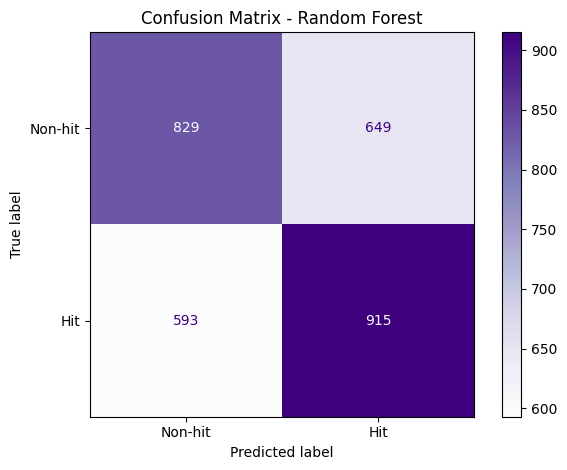

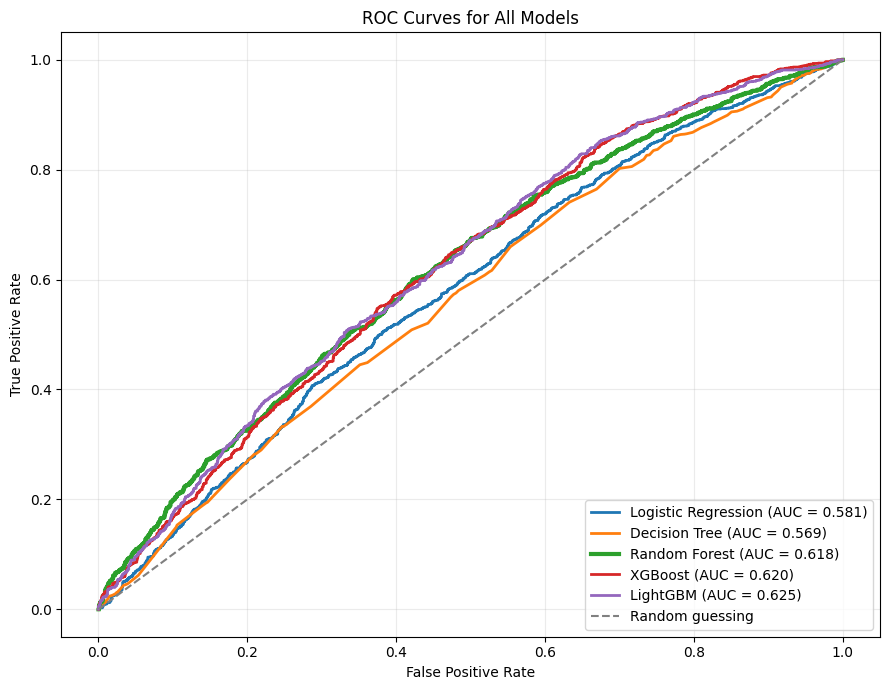


Most important features:


,feature,importance
6,numeric__loudness,0.084892
1,numeric__acousticness,0.082653
8,numeric__tempo,0.078572
11,numeric__mood_index,0.076466
2,numeric__danceability,0.076094
5,numeric__liveness,0.075807
3,numeric__energy,0.075751
9,numeric__audio_valence,0.075717
7,numeric__speechiness,0.075553
0,numeric__song_duration_ms,0.074365


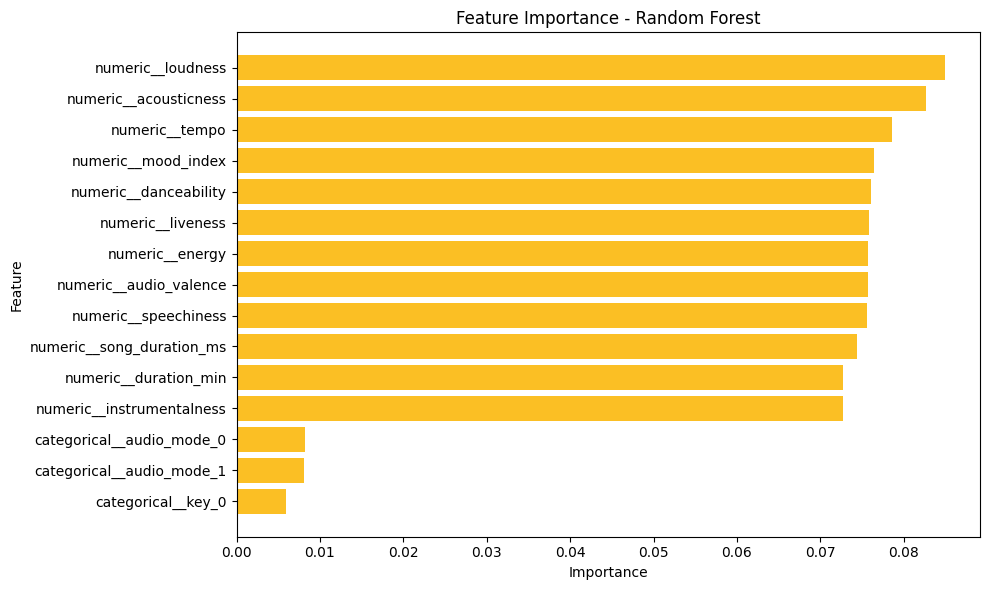


Files saved:
- model_comparison_results.csv
- feature_importance.csv
- song_popularity_predictions.csv
- song_popularity_best_model.joblib


In [8]:
# ============================================================
# REMAINING CODE AFTER TRAIN-TEST SPLIT
# ============================================================

import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ------------------------------------------------------------
# 1. Identify numeric and categorical features
# ------------------------------------------------------------

categorical_names = [
    "key",
    "audio_mode",
    "time_signature"
]

categorical_features = [
    column
    for column in categorical_names
    if column in X_train.columns
]

# Convert categorical columns to categorical/object type
for column in categorical_features:
    X_train[column] = X_train[column].astype("object")
    X_test[column] = X_test[column].astype("object")

numeric_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# 2. Create preprocessing pipeline
# ------------------------------------------------------------

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            encoder
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 3. Define the five presentation models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=350,
        learning_rate=0.03,
        num_leaves=31,
        objective="binary",
        verbosity=-1,
        random_state=42,
        n_jobs=-1
    )
}


# ------------------------------------------------------------
# 4. Five-fold cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []
fitted_models = {}


# ------------------------------------------------------------
# 5. Train and evaluate all five models
# ------------------------------------------------------------

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                clone(model)
            )
        ]
    )

    cv_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=1
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    fitted_models[model_name] = model_pipeline

    test_predictions = model_pipeline.predict(
        X_test
    )

    test_probabilities = (
        model_pipeline.predict_proba(X_test)[:, 1]
    )

    results.append({
        "Model": model_name,

        "CV Accuracy": cv_scores[
            "test_accuracy"
        ].mean(),

        "CV Precision": cv_scores[
            "test_precision"
        ].mean(),

        "CV Recall": cv_scores[
            "test_recall"
        ].mean(),

        "CV F1": cv_scores[
            "test_f1"
        ].mean(),

        "CV ROC-AUC": cv_scores[
            "test_roc_auc"
        ].mean(),

        "Test Accuracy": accuracy_score(
            y_test,
            test_predictions
        ),

        "Test Precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test Recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test F1": f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),

        "Test ROC-AUC": roc_auc_score(
            y_test,
            test_probabilities
        )
    })


# ------------------------------------------------------------
# 6. Model comparison
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\nModel comparison:")
display(results_df.round(4))

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Select the best model
# ------------------------------------------------------------

best_model_name = results_df.loc[
    results_df["CV ROC-AUC"].idxmax(),
    "Model"
]

best_model = fitted_models[
    best_model_name
]

best_predictions = best_model.predict(
    X_test
)

best_probabilities = (
    best_model.predict_proba(X_test)[:, 1]
)

print("\nBest model:", best_model_name)

print("\nFinal test metrics:")
print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            best_predictions
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            best_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            best_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_test,
            best_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            best_probabilities
        ),
        4
    )
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Non-hit", "Hit"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 8. Confusion matrix
# ------------------------------------------------------------

confusion = confusion_matrix(
    y_test,
    best_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Non-hit", "Hit"]
).plot(
    cmap="Purples",
    values_format="d"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. ROC curves for all five models
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for model_name, model_pipeline in fitted_models.items():

    probabilities = (
        model_pipeline.predict_proba(X_test)[:, 1]
    )

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    model_auc = roc_auc_score(
        y_test,
        probabilities
    )

    line_width = (
        3
        if model_name == best_model_name
        else 2
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=line_width,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random guessing"
)

plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Feature importance
# ------------------------------------------------------------

fitted_preprocessor = (
    best_model.named_steps["preprocessor"]
)

fitted_estimator = (
    best_model.named_steps["model"]
)

feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

if hasattr(
    fitted_estimator,
    "feature_importances_"
):
    importance_values = (
        fitted_estimator.feature_importances_
    )

elif hasattr(
    fitted_estimator,
    "coef_"
):
    importance_values = np.abs(
        fitted_estimator.coef_[0]
    )

else:
    importance_values = np.zeros(
        len(feature_names)
    )

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).head(15)

print("\nMost important features:")
display(feature_importance)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"].iloc[::-1],
    feature_importance["importance"].iloc[::-1],
    color="#FBBF24"
)

plt.title(
    f"Feature Importance - {best_model_name}"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Save validation predictions
# ------------------------------------------------------------

prediction_output = pd.DataFrame({
    "actual_is_hit": y_test.values,
    "predicted_is_hit": best_predictions,
    "hit_probability": best_probabilities
})

# Add popularity and song name when available
if "song_data" in globals():

    if "song_name" in song_data.columns:
        prediction_output.insert(
            0,
            "song_name",
            song_data.loc[
                X_test.index,
                "song_name"
            ].values
        )

    if "song_popularity" in song_data.columns:
        prediction_output.insert(
            1 if "song_name" in song_data.columns else 0,
            "actual_song_popularity",
            song_data.loc[
                X_test.index,
                "song_popularity"
            ].values
        )

prediction_output.to_csv(
    "song_popularity_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# 12. Save the best model
# ------------------------------------------------------------

joblib.dump(
    {
        "model": best_model,
        "model_name": best_model_name,
        "popularity_median": (
            song_data["song_popularity"].median()
            if "song_data" in globals()
            else None
        )
    },
    "song_popularity_best_model.joblib"
)

print("\nFiles saved:")
print("- model_comparison_results.csv")
print("- feature_importance.csv")
print("- song_popularity_predictions.csv")
print("- song_popularity_best_model.joblib")

In [9]:
%%writefile README.md

# Song Popularity Prediction

This project predicts whether a song is a hit or non-hit using audio features from the Kaggle Song Popularity Dataset.

## Workflow

- Exploratory data analysis
- Missing-value and duplicate checks
- Outlier inspection
- Feature engineering
- Creation of `duration_min`
- Creation of `mood_index`
- Median-based `is_hit` classification
- 80/20 stratified train-test split
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM

## Evaluation Metrics

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## Dataset

https://www.kaggle.com/datasets/yasserh/song-popularity-dataset

Writing README.md


In [10]:
!cat README.md


# Song Popularity Prediction

This project predicts whether a song is a hit or non-hit using audio features from the Kaggle Song Popularity Dataset.

## Workflow

- Exploratory data analysis
- Missing-value and duplicate checks
- Outlier inspection
- Feature engineering
- Creation of `duration_min`
- Creation of `mood_index`
- Median-based `is_hit` classification
- 80/20 stratified train-test split
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM

## Evaluation Metrics

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## Dataset

https://www.kaggle.com/datasets/yasserh/song-popularity-dataset
